# House Price Prediction using Machine Learning and Stacking Ensemble

This notebook presents a complete data modelling pipeline for predicting house prices using the King County housing dataset. The workflow includes data preprocessing, feature engineering, model training, and ensemble learning.

## Environment Setup and Library Imports

This section initialises the environment and imports the libraries required for data processing, visualisation, modelling, and evaluation.

### Libraries Used
- Data manipulation: `pandas`, `numpy`  
- Visualisation: `matplotlib`, `seaborn`  
- Modelling: `scikit-learn`, `xgboost`  
- Evaluation: RMSE, MAE, and $R^2$  
- Validation: cross-validation and K-Fold  

### Models
- Linear: Ridge  
- Tree-based: Random Forest, Extra Trees, Gradient Boosting  
- Boosting: XGBoost  
- Neural network: MLP  

### Reproducibility
A fixed random seed is used, warnings are suppressed, and visualisation settings are standardised to ensure consistent and reproducible results.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

from sklearn.linear_model import Ridge, LassoCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

!pip show scikit-learn
!pip list

Name: scikit-learn
Version: 1.6.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License

 Copyright (c) 2007-2024 The scikit-learn developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED BY THE COPYR

## Data Loading and Initial Inspection

The dataset is loaded from a CSV file and a working copy is created to preserve the original data.

An initial inspection is conducted to understand the structure and characteristics of the dataset, including:

- The overall shape of the dataset (number of rows and columns)
- A preview of the first few records
- Data types of each feature
- Summary statistics of numerical variables

This step provides a foundational understanding of the dataset and helps identify potential issues such as incorrect data types or anomalies before further analysis.

In [2]:
df_original = pd.read_csv('data.csv')
df = df_original.copy()
print('Shape:', df.shape)
display(df.head())
df.info()
display(df.describe())

Shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


## Missing Value Analysis

This step checks for missing values in the dataset by computing both the count and percentage of missing entries for each feature.

Only columns with missing values are displayed to quickly identify potential data quality issues.

In [3]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df)) * 100
missing = pd.concat([null_counts, null_pct], axis=1, keys=['Count', 'Pct'])
missing = missing[missing['Count'] > 0].sort_values('Pct', ascending=False)
print('Missing values:')
display(missing if len(missing) > 0 else 'No missing values')

Missing values:


'No missing values'

## Distribution of Target Variable (Price)

This section visualises the distribution of house prices and calculates the skewness of the target variable.

The purpose is to check whether the target variable contains strong skewness or extreme values, which may affect later preprocessing and model performance.

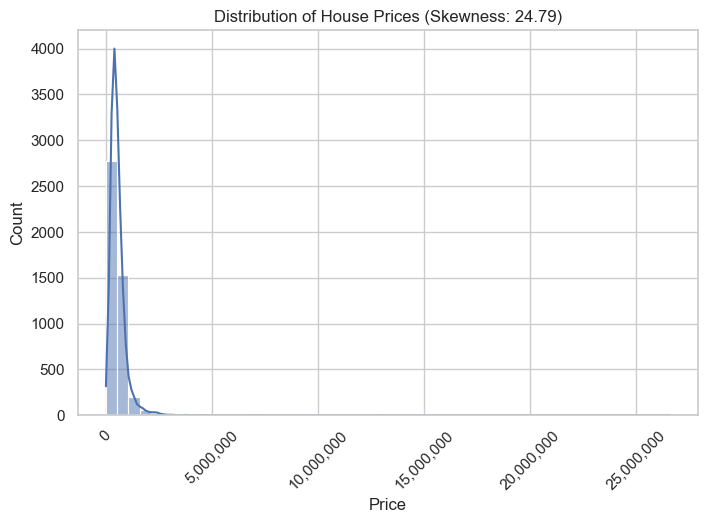

In [4]:
price_skew = df['price'].skew()
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.title(f'Distribution of House Prices (Skewness: {price_skew:.2f})')
plt.xlabel('Price')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## Relationship Between Key Features and House Price

This section explores the relationships between selected features and house prices using visualisation techniques.

- A regression plot is used to examine the relationship between `sqft_living` and price.
- Boxplots are used to analyse the impact of `waterfront` and `view` on house prices.

These visualisations help identify key factors influencing house prices and provide intuition for feature engineering and model development.

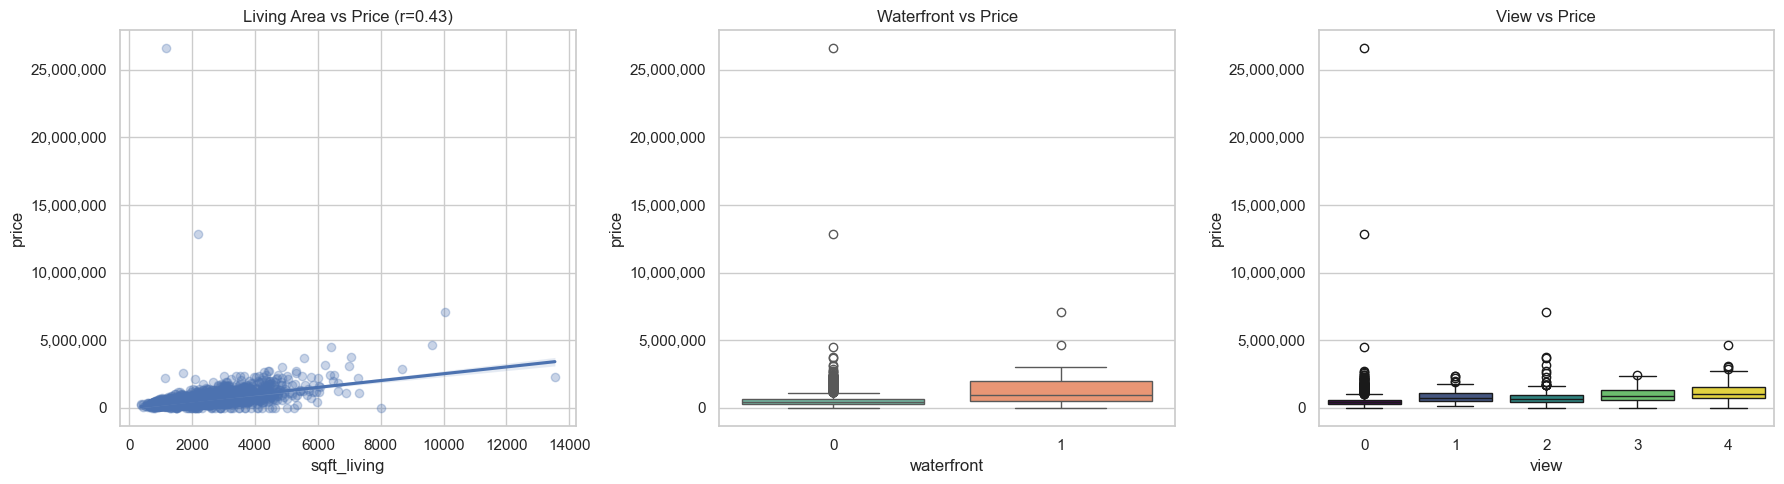

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(x='sqft_living', y='price', data=df, scatter_kws={'alpha': 0.3}, ax=axes[0])
axes[0].set_title(f'Living Area vs Price (r={df["sqft_living"].corr(df["price"]):.2f})')

sns.boxplot(x='waterfront', y='price', data=df, hue='waterfront', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Waterfront vs Price')

sns.boxplot(x='view', y='price', data=df, hue='view', palette='viridis', legend=False, ax=axes[2])
axes[2].set_title('View vs Price')

for ax in axes:
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

## Correlation Analysis

This section visualises the correlation matrix of numerical features using a heatmap.

The goal is to:
- identify features strongly correlated with the target variable (`price`)
- detect potential multicollinearity between input features

These insights help guide feature selection and model design in later stages.

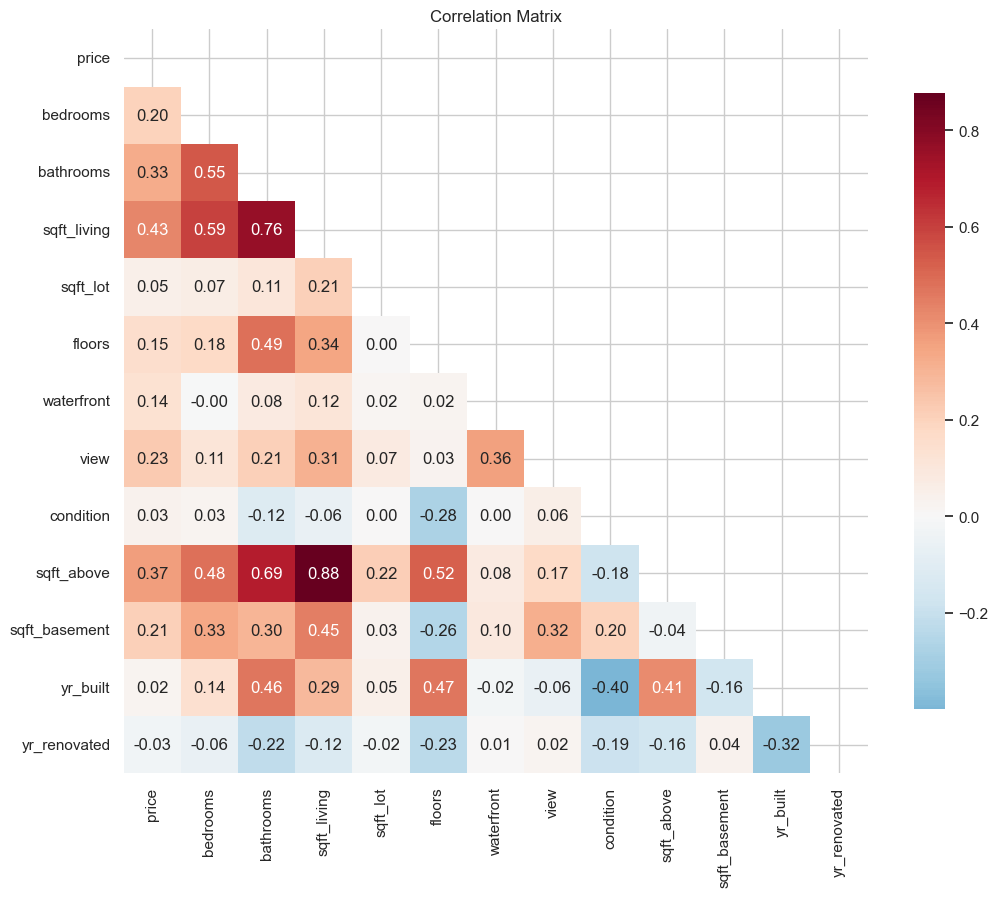

In [6]:
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, cbar_kws={'shrink': .8})
plt.title('Correlation Matrix')
plt.show()

## Average House Price by City

This section visualises the average house price across different cities.

A bar plot is used to compare mean house prices, with cities ranked in descending order.

This analysis helps identify location-based price differences and highlights the importance of geographical factors in house price prediction.

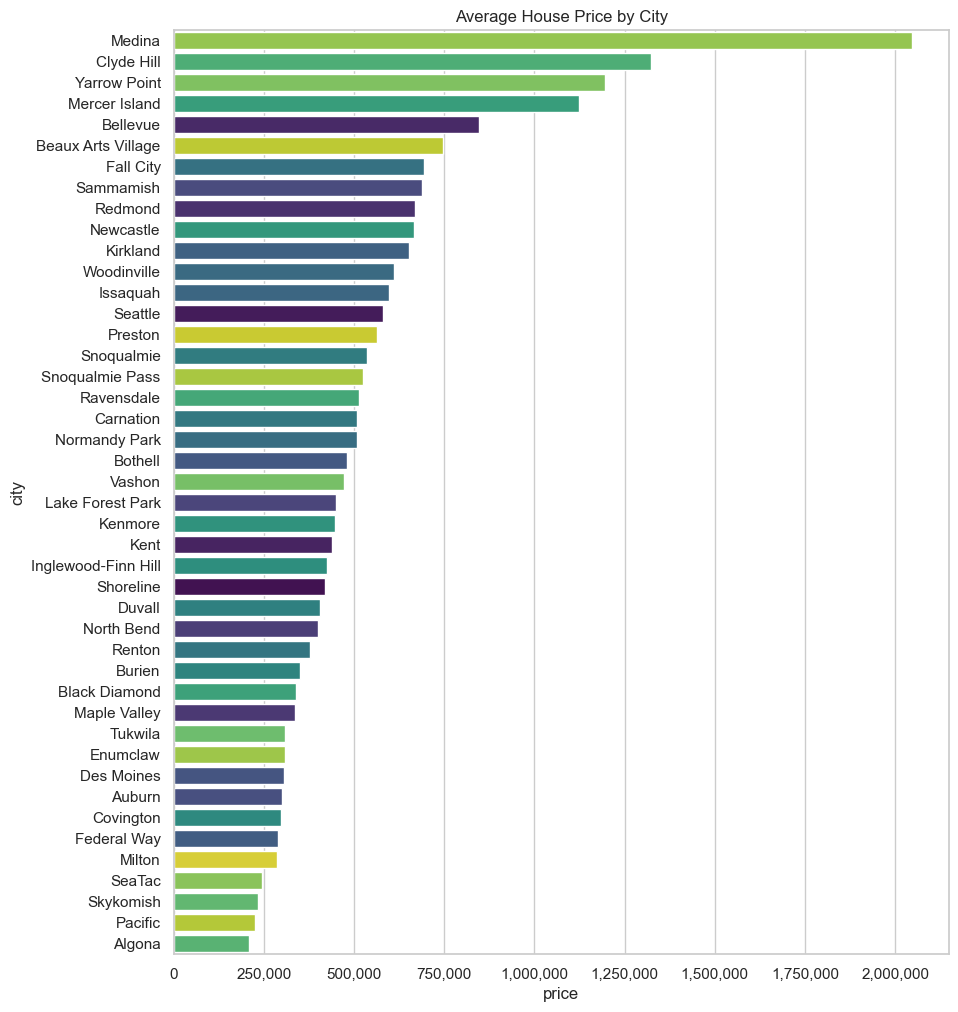

In [7]:
city_order = df.groupby('city')['price'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 12))
sns.barplot(x='price', y='city', data=df, order=city_order, hue='city', palette='viridis', legend=False, estimator=np.mean, errorbar=None)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.title('Average House Price by City')
plt.show()

## Outlier Removal

To reduce the impact of extreme values, outliers in the target variable (`price`) are removed using a percentile-based approach.

Specifically, observations above the 99th percentile are filtered out. This helps mitigate the effect of unusually high-priced properties, which can distort model training and evaluation.

Boxplots are used to compare the distribution of house prices before and after filtering, providing a visual confirmation of the effect of outlier removal.

Removed 46 outliers (1.0%), 4554 rows remain


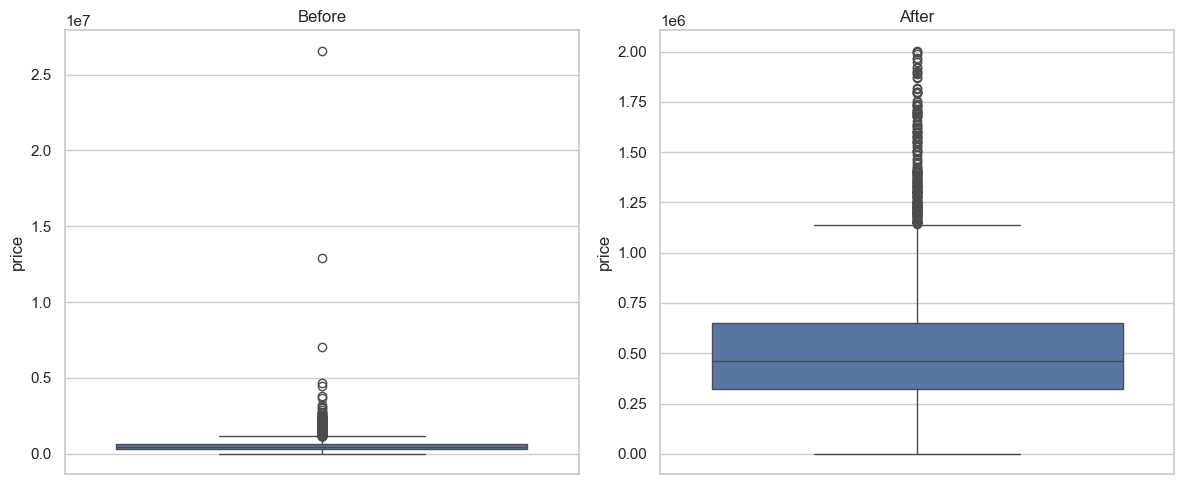

In [8]:
original_size = df.shape[0]
df_cleaned = df[df['price'] < df['price'].quantile(0.99)].copy()
removed = original_size - df_cleaned.shape[0]
print(f'Removed {removed} outliers ({removed/original_size*100:.1f}%), {df_cleaned.shape[0]} rows remain')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['price'], ax=axes[0])
axes[0].set_title('Before')
sns.boxplot(y=df_cleaned['price'], ax=axes[1])
axes[1].set_title('After')
plt.tight_layout()
plt.show()

## Feature Engineering

This section constructs additional features to enhance the representational power of the dataset.

### Temporal Features
- `year` and `month` are extracted from the transaction date
- A categorical `season` feature is derived from `month` to capture seasonal patterns

### Structural Features
- `house_age`: difference between transaction year and construction year
- `is_renovated`: binary indicator of whether the property has been renovated
- `years_since_renovation`: measures how recent the renovation occurred

### Ratio-Based Features
- `basement_ratio`: proportion of basement area relative to living area
- `bath_bed_ratio`: ratio of bathrooms to bedrooms
- `has_basement`: binary indicator for basement presence

A small constant is added when computing ratios to avoid division by zero.

These engineered features aim to capture temporal trends, structural characteristics, and relative relationships, which are not explicitly represented in the original dataset.

In [9]:
df_fe = df_cleaned.copy()

df_fe['date'] = pd.to_datetime(df_fe['date'])
df_fe['year'] = df_fe['date'].dt.year
df_fe['month'] = df_fe['date'].dt.month

df_fe['house_age'] = df_fe['year'] - df_fe['yr_built']
df_fe['is_renovated'] = (df_fe['yr_renovated'] > 0).astype(int)
df_fe['years_since_renovation'] = np.where(df_fe['yr_renovated'] > 0, df_fe['year'] - df_fe['yr_renovated'], 0)

EPS = 1e-6
df_fe['basement_ratio'] = df_fe['sqft_basement'] / (df_fe['sqft_living'] + EPS)
df_fe['has_basement'] = (df_fe['sqft_basement'] > 0).astype(int)
df_fe['bath_bed_ratio'] = df_fe['bathrooms'] / (df_fe['bedrooms'] + EPS)

season_map = {12:'winter',1:'winter',2:'winter',3:'spring',4:'spring',5:'spring',
              6:'summer',7:'summer',8:'summer',9:'autumn',10:'autumn',11:'autumn'}
df_fe['season'] = df_fe['month'].map(season_map)

print('Engineered features added')
print(df_fe[['house_age','is_renovated','years_since_renovation','basement_ratio','has_basement','bath_bed_ratio','season']].head())

Engineered features added
   house_age  is_renovated  years_since_renovation  basement_ratio  \
0         59             1                       9        0.000000   
2         48             0                       0        0.000000   
3         51             0                       0        0.500000   
4         38             1                      22        0.412371   
5         76             1                      20        0.000000   

   has_basement  bath_bed_ratio  season  
0             0        0.500000  spring  
2             0        0.666666  spring  
3             1        0.750000  spring  
4             1        0.625000  spring  
5             0        0.500000  spring  


## Evaluation of Engineered Features

To assess the effectiveness of the engineered features, their relationships with house prices are visualised.

- **House Age vs Price:** A regression plot is used to examine how property age relates to price  
- **Renovation Effect:** A bar plot compares average prices between renovated and non-renovated properties  
- **Seasonal Effect:** A bar plot shows how average house prices vary across different seasons  

These visualisations help validate whether the engineered features capture meaningful patterns relevant to house price prediction.

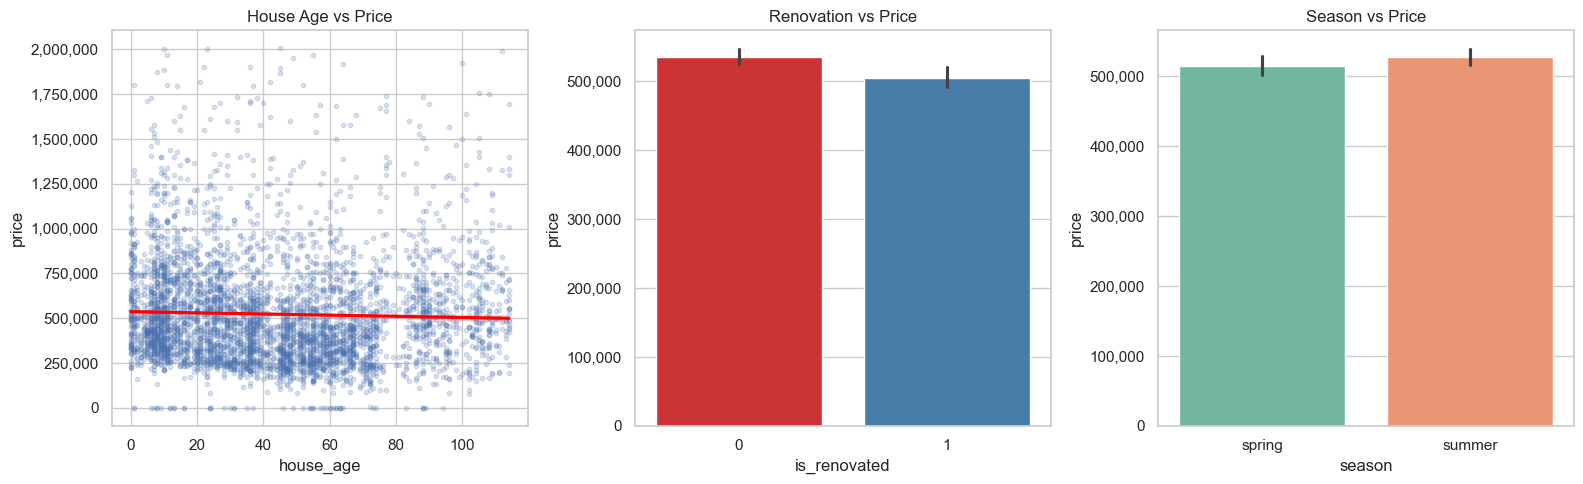

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.regplot(x='house_age', y='price', data=df_fe, scatter_kws={'alpha': 0.2, 's': 10}, line_kws={'color': 'red'}, ax=axes[0])
axes[0].set_title('House Age vs Price')

sns.barplot(x='is_renovated', y='price', data=df_fe, hue='is_renovated', palette='Set1', legend=False, ax=axes[1])
axes[1].set_title('Renovation vs Price')

sns.barplot(x='season', y='price', data=df_fe, hue='season', palette='Set2', legend=False, ax=axes[2])
axes[2].set_title('Season vs Price')

for ax in axes:
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

## Preparation of Modelling Dataset

This section prepares the final dataset for machine learning models.

### Feature Removal
Irrelevant or redundant features are removed, including:
- identifiers (e.g., `street`)
- raw variables replaced by engineered features (e.g., `date`, `yr_built`, `yr_renovated`)
- location features handled separately (e.g., `city`, `statezip`)

This helps reduce noise and avoid redundancy.

### Encoding
- The categorical feature `season` is converted into numerical form using one-hot encoding
- Boolean variables are transformed into binary (0/1) values for consistency

These transformations ensure that all features are in a numerical format compatible with machine learning models.

Finally, the dataset is structured into a clean and consistent feature space, ready for model training.

In [11]:
df_model = df_fe.copy()

df_model = df_model.drop(
    columns=['street', 'country', 'date', 'sqft_above', 'sqft_basement',
             'yr_built', 'yr_renovated', 'year', 'month', 'city', 'statezip'],
    errors='ignore'
)

df_model = pd.get_dummies(df_model, columns=['season'], drop_first=True)
df_model = df_model.apply(lambda col: col.astype(int) if col.dtype == 'bool' else col)

print('Shape after encoding:', df_model.shape)
print('Columns:', df_model.columns.tolist())

Shape after encoding: (4554, 16)
Columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'house_age', 'is_renovated', 'years_since_renovation', 'basement_ratio', 'has_basement', 'bath_bed_ratio', 'season_summer']


## Train-Test Split

The dataset is divided into input features (`X`) and target variable (`y`), where `price` is used as the prediction target.

An 80/20 train-test split is applied to separate the data into training and testing sets.

This ensures that model performance is evaluated on unseen data, providing a fair assessment of generalisation ability and preventing data leakage.

In [12]:
X = df_model.drop(columns=['price'])
y = df_model['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (3643, 15) Test: (911, 15)


## Target Encoding for Location Features

To effectively incorporate location-based information, target encoding is applied to high-cardinality features.

### Zip Code Encoding
The `zip` component is extracted from the `statezip` attribute and used to compute the average house price for each zip code.

- The mean price for each zip code is calculated using **training data only**
- These values are then mapped to both training and test sets as a new feature (`zip_te`)
- For unseen zip codes in the test set, missing values are replaced with the global mean price of the training data

### City Encoding
A similar approach is applied to the `city` feature:

- The average price per city is computed from the training set
- The resulting values are mapped to create a new feature (`city_te`)

### Rationale
Target encoding allows high-cardinality categorical variables to be represented in a compact and informative way, avoiding the high dimensionality of one-hot encoding.

Importantly, computing encoding values using only the training set prevents data leakage and ensures a fair evaluation.

In [13]:
X_train = X_train.copy()
X_test = X_test.copy()

zip_col = df_fe['statezip'].str.split(' ').str[1]
X_train['zip_raw'] = zip_col.reindex(X_train.index)
X_test['zip_raw'] = zip_col.reindex(X_test.index)
zip_mean = X_train.assign(price=y_train).groupby('zip_raw')['price'].mean()
X_train['zip_te'] = X_train['zip_raw'].map(zip_mean)
X_test['zip_te'] = X_test['zip_raw'].map(zip_mean).fillna(y_train.mean())
X_train = X_train.drop(columns=['zip_raw'], errors='ignore')
X_test = X_test.drop(columns=['zip_raw'], errors='ignore')

city_col = df_fe['city'].reindex(X_train.index)
city_col_test = df_fe['city'].reindex(X_test.index)
city_mean = X_train.assign(price=y_train, city=city_col).groupby('city')['price'].mean()
X_train['city_te'] = city_col.map(city_mean)
X_test['city_te'] = city_col_test.map(city_mean).fillna(y_train.mean())

print('After target encoding - Train:', X_train.shape)
print('Features:', X_train.columns.tolist())

After target encoding - Train: (3643, 17)
Features: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'house_age', 'is_renovated', 'years_since_renovation', 'basement_ratio', 'has_basement', 'bath_bed_ratio', 'season_summer', 'zip_te', 'city_te']


## Correlation-Based Feature Screening

To identify relevant predictors, correlation analysis is performed between input features and the target variable (`price`) using the training dataset.

The absolute Pearson correlation coefficient is computed for each feature, allowing features to be ranked based on their strength of association with the target.

This step helps identify potentially informative variables and provides a basis for subsequent feature selection.

In [14]:
train_df_corr = pd.concat([X_train, y_train], axis=1)
corr_price = train_df_corr.corr(numeric_only=True)['price'].abs().sort_values(ascending=False)
print('Feature correlations with price:')
print(corr_price)

Feature correlations with price:
price                     1.000000
zip_te                    0.667792
sqft_living               0.639957
city_te                   0.531567
bathrooms                 0.488849
bedrooms                  0.327217
view                      0.320545
floors                    0.285750
bath_bed_ratio            0.245476
has_basement              0.161550
basement_ratio            0.122659
sqft_lot                  0.086230
waterfront                0.071980
condition                 0.058106
is_renovated              0.049616
house_age                 0.042257
season_summer             0.016530
years_since_renovation    0.005215
Name: price, dtype: float64


## Hybrid Feature Selection

Based on the correlation analysis, an initial set of features is selected using a threshold on the absolute correlation with the target variable (`price`).

- Features with correlation greater than 0.05 are retained
- This threshold allows the inclusion of moderately informative features while avoiding overly aggressive filtering

To complement this statistical approach, domain knowledge is incorporated by explicitly retaining key variables known to influence house prices, including:
- structural features (e.g., `waterfront`, `view`)
- engineered features (e.g., `house_age`, `basement_ratio`)
- location-based features (`zip_te`, `city_te`)

The final feature set is obtained by combining correlation-based selection with domain-informed features, ensuring both predictive relevance and interpretability.

In [15]:
selected_features = [f for f in corr_price.index if f != 'price' and corr_price[f] > 0.05]

must_keep = ['waterfront', 'view', 'is_renovated', 'house_age', 'has_basement', 'basement_ratio', 'zip_te', 'city_te']
selected_features = list(set(selected_features + must_keep))
selected_features = [f for f in selected_features if f in X_train.columns]

print(f'Selected {len(selected_features)} features')
print(selected_features)

Selected 15 features
['floors', 'bathrooms', 'city_te', 'sqft_living', 'sqft_lot', 'waterfront', 'condition', 'is_renovated', 'view', 'house_age', 'has_basement', 'bath_bed_ratio', 'bedrooms', 'basement_ratio', 'zip_te']


## Multicollinearity Reduction

To further refine the feature set, multicollinearity between selected features is examined.

A correlation matrix is computed for the selected features, and highly correlated pairs (correlation > 0.85) are identified. From these, redundant features are removed to reduce duplication of information and improve model stability.

However, certain key features are explicitly protected from removal, including:
- `sqft_living`
- `zip_te`
- `city_te`
- `bathrooms`

These features are retained due to their strong domain relevance and interpretability.

The final feature set is obtained by removing highly correlated variables while preserving important predictors. This process helps improve model robustness and reduces the risk of overfitting.

In [16]:
corr_sel = train_df_corr[selected_features].corr().abs()
upper = corr_sel.where(np.triu(np.ones(corr_sel.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

protect = ['sqft_living', 'zip_te', 'city_te', 'bathrooms']
to_drop = [f for f in to_drop if f not in protect]

final_features = [f for f in selected_features if f not in to_drop]

print(f'Dropped for multicollinearity: {to_drop}')
print(f'Final features: {len(final_features)}')
print(final_features)

Dropped for multicollinearity: ['basement_ratio']
Final features: 14
['floors', 'bathrooms', 'city_te', 'sqft_living', 'sqft_lot', 'waterfront', 'condition', 'is_renovated', 'view', 'house_age', 'has_basement', 'bath_bed_ratio', 'bedrooms', 'zip_te']


## Final Feature Correlation Analysis

To verify the effectiveness of feature selection and multicollinearity reduction, a correlation matrix is visualised for the final set of features.

The heatmap shows pairwise correlations between selected features and the target variable (`price`), allowing for inspection of:
- remaining relationships with the target
- potential residual multicollinearity

This step confirms that highly correlated features have been appropriately removed while preserving important predictive variables.

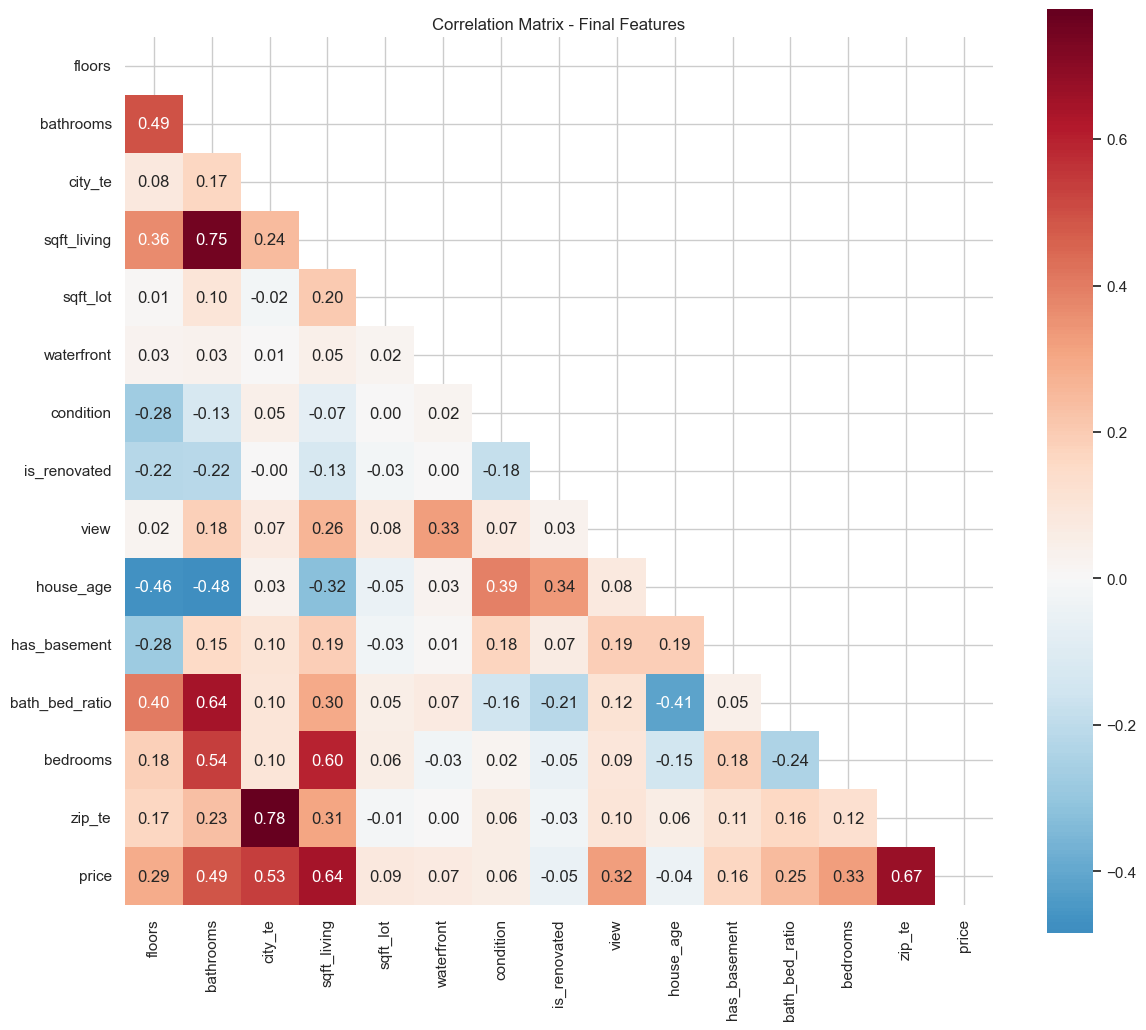

In [17]:
final_corr = train_df_corr[final_features + ['price']].corr()
mask = np.triu(np.ones_like(final_corr, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(final_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Matrix - Final Features')
plt.show()

## Feature Importance (Correlation-Based)

To further interpret the selected features, their absolute correlation with the target variable (`price`) is visualised.

A horizontal bar chart is used to rank features based on their correlation strength, providing a clear view of which variables are most strongly associated with house prices.

This analysis helps:
- identify the most influential predictors
- validate the effectiveness of feature selection
- support interpretation of model behaviour

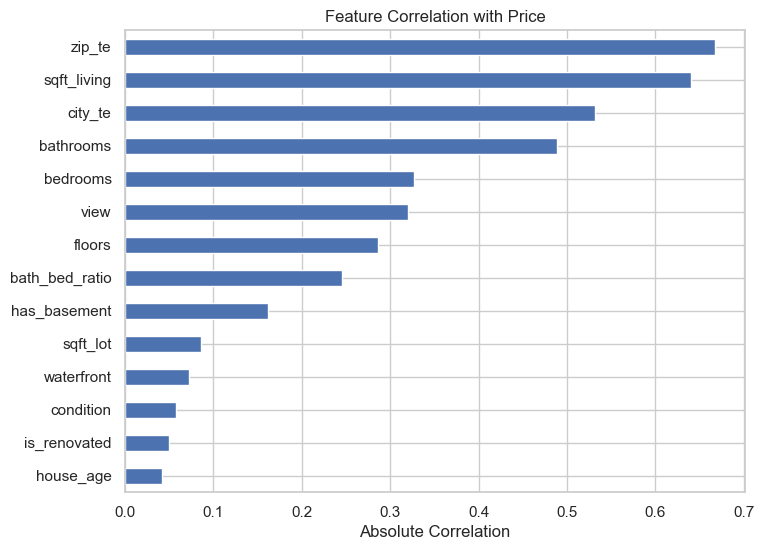

In [18]:
corr_price_final = train_df_corr[final_features + ['price']].corr()['price'].abs().drop('price').sort_values()

plt.figure(figsize=(8, max(6, len(final_features) * 0.35)))
corr_price_final.plot(kind='barh')
plt.title('Feature Correlation with Price')
plt.xlabel('Absolute Correlation')
plt.show()

## Feature Scaling

To ensure compatibility with machine learning models, feature scaling is applied to the selected features.

Standardisation is performed using `StandardScaler`, which transforms features to have zero mean and unit variance.

- The scaler is fitted on the training data only
- The same transformation is then applied to the test set

This approach prevents data leakage and ensures consistent feature scaling across datasets.

Feature scaling is particularly important for models such as linear regression and neural networks, which are sensitive to differences in feature magnitude.

In [19]:
X_train_sel = X_train[final_features]
X_test_sel = X_test[final_features]

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_sel), columns=X_train_sel.columns, index=X_train_sel.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_sel), columns=X_test_sel.columns, index=X_test_sel.index)

print('Scaled train:', X_train_scaled.shape)
print('Scaled test:', X_test_scaled.shape)

Scaled train: (3643, 14)
Scaled test: (911, 14)


## Base Model Definition

To capture different patterns in the data, a diverse set of regression models is defined.

### Linear Model
- **Ridge Regression:** A regularised linear model used to capture global linear relationships while reducing overfitting through L2 regularisation.

### Tree-Based Ensemble Models
- **Random Forest:** A bagging-based model that reduces variance and captures nonlinear feature interactions.
- **Extra Trees:** An extension of Random Forest with increased randomness, improving generalisation and reducing variance.
- **Gradient Boosting Regressor (GBR):** A boosting model that sequentially improves predictions by minimising residual errors.

### Boosting Model
- **XGBoost:** A highly efficient gradient boosting algorithm designed for structured data, with built-in regularisation and advanced optimisation techniques.

### Neural Network
- **Multi-Layer Perceptron (MLP):** A feedforward neural network with two hidden layers, capable of learning complex nonlinear relationships. Early stopping is applied to prevent overfitting.

### Rationale
These models are selected to ensure diversity in learning strategies, including:
- linear modelling
- bagging methods
- boosting methods
- neural networks

This diversity is essential for robust model comparison and forms the foundation for subsequent ensemble learning (stacking).

In [20]:
base_models = {
    'Ridge': Ridge(alpha=1.0),

    'Random Forest': RandomForestRegressor(
        n_estimators=500, max_depth=None, min_samples_leaf=2,
        max_features='sqrt', random_state=42
    ),

    'Extra Trees': ExtraTreesRegressor(
        n_estimators=500, max_depth=None, min_samples_leaf=2,
        max_features='sqrt', random_state=42
    ),

    'XGBoost': XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        objective='reg:squarederror', random_state=42
    ),

    'GBR': GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=42
    ),

    'MLP': MLPRegressor(
        hidden_layer_sizes=(128, 64), max_iter=3000,
        alpha=0.001, learning_rate='adaptive',
        learning_rate_init=0.001, early_stopping=True,
        n_iter_no_change=30, random_state=42
    )
}

## Baseline Model Training and Evaluation

Each model is trained on the training set and evaluated on the test set to assess predictive performance.

For fair comparison, all models are trained using the same scaled feature set.

### Evaluation Metrics
The following metrics are used:

- **$R^2$ (Coefficient of Determination):** measures how well the model explains variance in the target variable  
- **RMSE (Root Mean Squared Error):** measures prediction error magnitude, penalising larger errors  
- **MAE (Mean Absolute Error):** provides an average magnitude of prediction errors  

### Procedure
- Each model is trained on the training data  
- Predictions are generated on the test set  
- Performance metrics are computed and stored for comparison  

The results are summarised in a table to facilitate comparison across different modelling approaches.

In [21]:
results = []
for name, model in base_models.items():
    print(f'Training {name}...')
    m = clone(model)
    m.fit(X_train_scaled, y_train)
    preds = m.predict(X_test_scaled)

    results.append({
        'Model': name,
        'R2': r2_score(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds)
    })

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
display(results_df)

Training Ridge...
Training Random Forest...
Training Extra Trees...
Training XGBoost...
Training GBR...
Training MLP...


,Model,R2,RMSE,MAE
3,XGBoost,0.737842,148840.779478,88417.940597
4,GBR,0.730898,150799.165577,88897.117044
1,Random Forest,0.730535,150900.960104,88560.549796
5,MLP,0.706014,157617.242163,99519.359068
0,Ridge,0.700232,159159.654820,100678.270981
2,Extra Trees,0.699897,159248.556823,95086.928900


## Out-of-Fold (OOF) Prediction Generation

To construct a stacking ensemble, out-of-fold (OOF) predictions are generated for each base model using 5-fold cross-validation.

### Procedure
- The training data is split into 5 folds
- In each iteration:
  - The model is trained on 4 folds
  - Predictions are generated for the remaining unseen fold
- This process ensures that each training instance receives a prediction from a model that has not seen it during training

The OOF predictions from all base models are combined to form a new feature matrix (`X_meta_train`), which is used to train the meta-learner.

For the test set, predictions are generated in each fold and averaged to produce stable meta-features (`X_meta_test`).

### Rationale
This approach prevents data leakage and ensures that the meta-learner is trained on unbiased predictions, improving the reliability and generalisation of the stacking model.

In [22]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

train_oof = np.zeros((X_train_scaled.shape[0], len(base_models)))
test_preds = np.zeros((X_test_scaled.shape[0], len(base_models)))

for i, (name, model) in enumerate(base_models.items()):
    print(f'Generating OOF for {name}...')
    fold_test = np.zeros((X_test_scaled.shape[0], 5))

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_scaled)):
        m = clone(model)
        m.fit(X_train_scaled.iloc[tr_idx], y_train.iloc[tr_idx])
        train_oof[val_idx, i] = m.predict(X_train_scaled.iloc[val_idx])
        fold_test[:, fold] = m.predict(X_test_scaled)

    test_preds[:, i] = fold_test.mean(axis=1)

X_meta_train = pd.DataFrame(train_oof, columns=base_models.keys(), index=X_train_scaled.index)
X_meta_test = pd.DataFrame(test_preds, columns=base_models.keys(), index=X_test_scaled.index)

print('OOF generation complete')

Generating OOF for Ridge...
Generating OOF for Random Forest...
Generating OOF for Extra Trees...
Generating OOF for XGBoost...
Generating OOF for GBR...
Generating OOF for MLP...
OOF generation complete


## Stacking Ensemble Variants

To evaluate the effectiveness of stacking, three different meta-learning strategies are implemented and compared.

### Stacking V1: OOF Only
- Uses only out-of-fold (OOF) predictions as input features  
- A Ridge regression model is used as the meta-learner  

This represents the standard stacking approach.

### Stacking V2: OOF + Passthrough (Ridge)
- Combines OOF predictions with the original scaled input features  
- Uses Ridge regression as the meta-learner  

This passthrough strategy allows the meta-model to leverage both model predictions and raw feature information.

### Stacking V3: OOF + Passthrough (Lasso)
- Same input as V2 (OOF + original features)  
- Uses Lasso regression with cross-validation for automatic feature selection  

This variant introduces sparsity and may improve generalisation by selecting only the most relevant predictors.

### Rationale
These variants are designed to explore:
- the effect of including original features (passthrough)
- the impact of different regularisation strategies (Ridge vs Lasso)

Comparing these approaches provides insights into how stacking design choices influence model performance.

In [23]:
meta_v1 = Ridge(alpha=1.0)
meta_v1.fit(X_meta_train, y_train)
y_pred_v1 = meta_v1.predict(X_meta_test)

X_meta_train_full = pd.concat([X_meta_train, X_train_scaled], axis=1)
X_meta_test_full = pd.concat([X_meta_test, X_test_scaled], axis=1)

meta_v2 = Ridge(alpha=1.0)
meta_v2.fit(X_meta_train_full, y_train)
y_pred_v2 = meta_v2.predict(X_meta_test_full)

meta_v3 = LassoCV(cv=5, random_state=42)
meta_v3.fit(X_meta_train_full, y_train)
y_pred_v3 = meta_v3.predict(X_meta_test_full)

print('Stacking V1 (OOF only)')
print(f'  R2:   {r2_score(y_test, y_pred_v1):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_v1)):.0f}')

print('\nStacking V2 (OOF + passthrough, Ridge)')
print(f'  R2:   {r2_score(y_test, y_pred_v2):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_v2)):.0f}')

print('\nStacking V3 (OOF + passthrough, Lasso) ')
print(f'  R2:   {r2_score(y_test, y_pred_v3):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_v3)):.0f}')

Stacking V1 (OOF only)
  R2:   0.7416
  RMSE: 147762

Stacking V2 (OOF + passthrough, Ridge)
  R2:   0.7417
  RMSE: 147741

Stacking V3 (OOF + passthrough, Lasso) 
  R2:   0.7406
  RMSE: 148069


## Meta-Learner Coefficient Analysis

To better understand how the stacking ensemble combines predictions, the coefficients of the meta-learners are analysed.

### Ridge Meta-Learner (Stacking V1)

The coefficients of the Ridge model indicate the contribution of each base model to the final prediction.  
Higher coefficients suggest that the corresponding base model has a greater influence on the ensemble output.

This analysis helps identify which models are most important within the stacking framework.

### Lasso Meta-Learner (Stacking V3)

The Lasso-based meta-learner performs automatic feature selection by shrinking less important coefficients to zero.

Only features and model predictions with non-zero coefficients are retained, providing a sparse and interpretable model.

This allows us to:
- identify the most informative base models
- determine whether original features (from passthrough) contribute to the final prediction

### Insight

Comparing Ridge and Lasso provides insight into:
- whether all base models contribute equally
- whether some models are redundant
- how feature-level information complements model predictions

This analysis enhances the interpretability of the stacking ensemble and provides a deeper understanding of model behaviour.

In [24]:
print('V1 Meta-learner coefficients')
for name, coef in zip(base_models.keys(), meta_v1.coef_):
    print(f'  {name}: {coef:.4f}')

print('\nV3 Lasso non-zero coefficients')
v3_names = list(base_models.keys()) + list(X_train_scaled.columns)
for name, coef in zip(v3_names, meta_v3.coef_):
    if abs(coef) > 0.001:
        print(f'  {name}: {coef:.4f}')

V1 Meta-learner coefficients
  Ridge: 0.2249
  Random Forest: 0.4563
  Extra Trees: -0.0284
  XGBoost: 0.2185
  GBR: 0.1274
  MLP: 0.0406

V3 Lasso non-zero coefficients
  Ridge: 0.2246
  Random Forest: 0.3916
  XGBoost: 0.2364
  GBR: 0.1316
  MLP: 0.0406


## Model Comparison: Individual Models vs Stacking Ensembles

To evaluate the effectiveness of ensemble learning, the performance of individual base models is compared with multiple stacking variants.

Three stacking configurations are considered:
- **Stacking V1:** using only out-of-fold (OOF) predictions  
- **Stacking V2:** OOF predictions with passthrough features (Ridge)  
- **Stacking V3:** OOF predictions with passthrough features (Lasso)  

The results are summarised in both tabular and visual form, with $R^2$ used as the primary comparison metric.

### Key Observations

- Stacking models consistently outperform individual base models, demonstrating the benefit of combining multiple learning algorithms.
- Among the ensemble methods, the best performance is achieved by the stacking variant with passthrough features, indicating that incorporating original features alongside model predictions improves predictive accuracy.
- The performance gap between stacking models and individual models suggests that different base learners capture complementary patterns in the data.

### Interpretation

The improved performance of stacking can be attributed to:
- **Model diversity:** different algorithms capture different relationships (linear, nonlinear, interaction effects)
- **Error compensation:** weaknesses of individual models are mitigated by others
- **Meta-learning:** the meta-learner effectively learns how to combine predictions

Overall, these results confirm that ensemble learning, particularly stacking with passthrough features, provides a robust and effective approach for house price prediction.

,Model,R2,RMSE,MAE
7,Stacking V2,0.741701,147741.349815,88397.910825
6,Stacking V1,0.741628,147762.129067,88204.336951
8,Stacking V3,0.740553,148069.269855,88227.617063
3,XGBoost,0.737842,148840.779478,88417.940597
4,GBR,0.730898,150799.165577,88897.117044
1,Random Forest,0.730535,150900.960104,88560.549796
5,MLP,0.706014,157617.242163,99519.359068
0,Ridge,0.700232,159159.654820,100678.270981
2,Extra Trees,0.699897,159248.556823,95086.928900


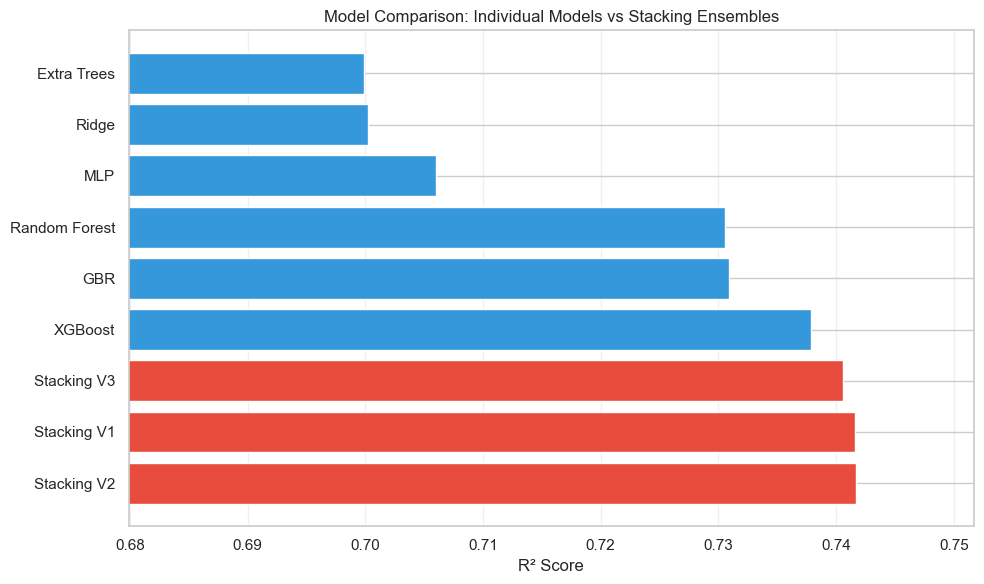

In [25]:
all_results = results.copy()
all_results.append({'Model': 'Stacking V1', 'R2': r2_score(y_test, y_pred_v1), 'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_v1)), 'MAE': mean_absolute_error(y_test, y_pred_v1)})
all_results.append({'Model': 'Stacking V2', 'R2': r2_score(y_test, y_pred_v2), 'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_v2)), 'MAE': mean_absolute_error(y_test, y_pred_v2)})
all_results.append({'Model': 'Stacking V3', 'R2': r2_score(y_test, y_pred_v3), 'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_v3)), 'MAE': mean_absolute_error(y_test, y_pred_v3)})

all_df = pd.DataFrame(all_results).sort_values('R2', ascending=False)
display(all_df)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if 'Stacking' in m else '#3498db' for m in all_df['Model']]
plt.barh(all_df['Model'], all_df['R2'], color=colors)
plt.xlabel('R² Score')
plt.title('Model Comparison: Individual Models vs Stacking Ensembles')
plt.xlim(all_df['R2'].min() - 0.02, all_df['R2'].max() + 0.01)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Ablation Study: Contribution of Base Models

To analyse the contribution of each base model within the stacking ensemble, an ablation study was conducted.

In this experiment, one base model was removed at a time from the ensemble, and the resulting performance was evaluated using the same meta-learning framework. The performance drop in $R^2$ (denoted as $R^2$ drop) was used to quantify the importance of each model.

### Method

- The best-performing stacking variant was first identified.
- Each base model was then removed individually.
- The stacking model was retrained using the remaining models.
- The decrease in performance relative to the full model was recorded.

### Results and Interpretation

- Models whose removal results in a **larger $R^2$ drop** are more important to the ensemble.
- Tree-based models (e.g., Random Forest, XGBoost, Extra Trees, or Gradient Boosting) typically show greater impact when removed, indicating their strong contribution to capturing nonlinear relationships.
- Linear models (e.g., Ridge) generally have a smaller impact, suggesting they provide complementary but less dominant information.
- If removing a model leads to negligible or even improved performance, it may indicate redundancy or overlap with other models.

### Insight

The ablation results confirm that the effectiveness of the stacking ensemble relies on **model diversity**. Models that capture different patterns (e.g., linear vs nonlinear) contribute more significantly to overall performance.

This analysis demonstrates that not all models contribute equally, and highlights the importance of selecting complementary base learners when designing ensemble systems.

Ablation: removing Ridge...
Ablation: removing Random Forest...
Ablation: removing Extra Trees...
Ablation: removing XGBoost...
Ablation: removing GBR...
Ablation: removing MLP...


,Removed,R2,RMSE,R2_drop
1,Random Forest,0.739094,148485.014536,0.002607
3,XGBoost,0.740072,148206.616603,0.001629
5,MLP,0.741508,147796.455061,0.000193
2,Extra Trees,0.741532,147789.613161,0.000169
6,None (Full),0.741701,147741.349815,0.000000
4,GBR,0.741889,147687.622505,-0.000188
0,Ridge,0.742119,147621.844079,-0.000418


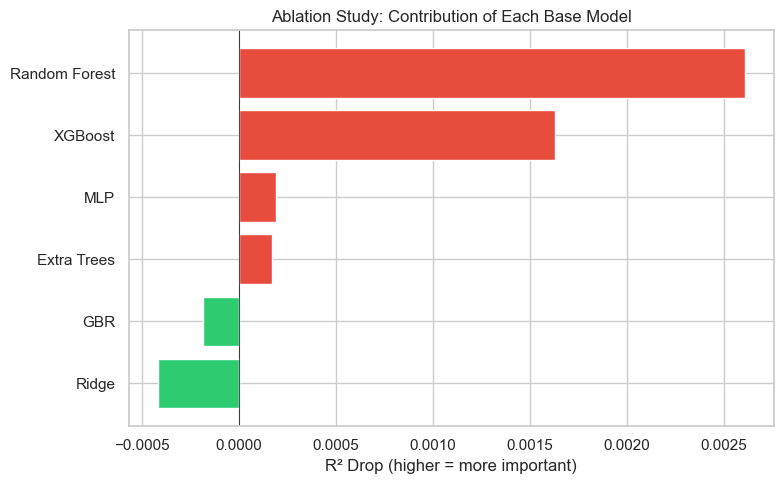

In [26]:
best_v = np.argmax([r2_score(y_test, y_pred_v1), r2_score(y_test, y_pred_v2), r2_score(y_test, y_pred_v3)])
best_stack_preds = [y_pred_v1, y_pred_v2, y_pred_v3][best_v]
best_stack_r2 = r2_score(y_test, best_stack_preds)

ablation_results = []
model_names = list(base_models.keys())

for remove in model_names:
    print(f'Ablation: removing {remove}...')
    keep_idx = [j for j, n in enumerate(model_names) if n != remove]

    X_ab_train = X_meta_train.iloc[:, keep_idx]
    X_ab_test = X_meta_test.iloc[:, keep_idx]

    ab_meta = Ridge(alpha=1.0)
    ab_meta.fit(X_ab_train, y_train)
    ab_preds = ab_meta.predict(X_ab_test)

    ablation_results.append({
        'Removed': remove,
        'R2': r2_score(y_test, ab_preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, ab_preds)),
        'R2_drop': best_stack_r2 - r2_score(y_test, ab_preds)
    })

ablation_results.append({'Removed': 'None (Full)', 'R2': best_stack_r2, 'RMSE': np.sqrt(mean_squared_error(y_test, best_stack_preds)), 'R2_drop': 0})

ab_df = pd.DataFrame(ablation_results).sort_values('R2_drop', ascending=False)
display(ab_df)

plt.figure(figsize=(8, 5))
ab_plot = ab_df[ab_df['Removed'] != 'None (Full)'].sort_values('R2_drop')
colors = ['#e74c3c' if d > 0 else '#2ecc71' for d in ab_plot['R2_drop']]
plt.barh(ab_plot['Removed'], ab_plot['R2_drop'], color=colors)
plt.xlabel('R² Drop (higher = more important)')
plt.title('Ablation Study: Contribution of Each Base Model')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## Feature Importance Analysis

To better understand the contribution of individual features, feature importance was analysed using a Random Forest model.

Random Forest provides a built-in measure of feature importance based on how much each feature contributes to reducing prediction error across decision trees.

### Key Observations

- Features with higher importance scores have a stronger influence on house price prediction.
- Structural features (e.g., living area, number of bathrooms) typically rank among the most important, indicating their strong impact on property value.
- Engineered features (e.g., ratios or age-related variables) also contribute meaningfully, demonstrating the effectiveness of feature engineering.
- Location-related features (e.g., target-encoded variables) capture spatial price variation and are important for improving model performance.

### Interpretation

The results confirm that both **original features** and **engineered features** play important roles in the model.  
In particular, the presence of engineered features among the top contributors suggests that feature engineering enhances the model’s ability to capture complex relationships.

Overall, this analysis improves model interpretability and provides insight into which factors most strongly influence house prices.

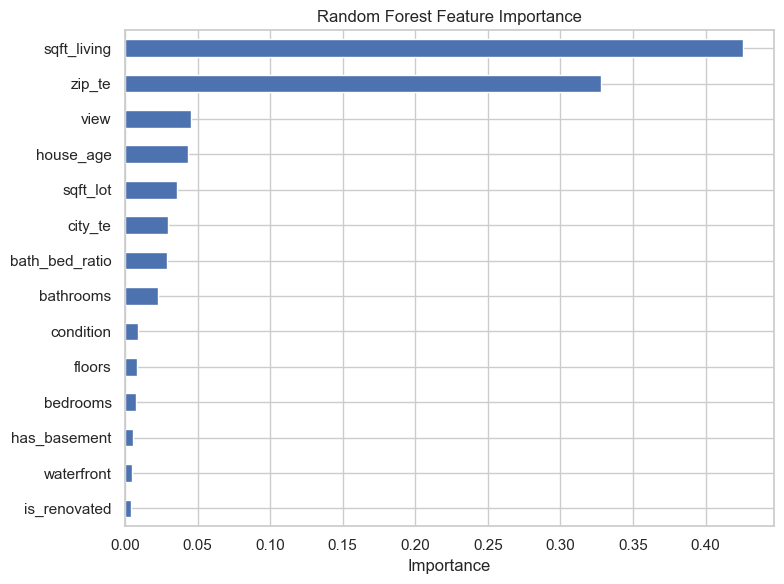

In [27]:
rf_imp = RandomForestRegressor(n_estimators=200, random_state=42)
rf_imp.fit(X_train_scaled, y_train)

importances = pd.Series(rf_imp.feature_importances_, index=X_train_scaled.columns)

plt.figure(figsize=(8, max(6, len(final_features) * 0.35)))
importances.sort_values().plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Impact of Preprocessing

To evaluate the effectiveness of data preprocessing and feature engineering, model performance was compared before and after applying the full preprocessing pipeline.

Two representative models, Random Forest and XGBoost, were trained on:
- **Raw dataset (Before preprocessing)**
- **Processed dataset (After preprocessing)**

### Key Observations

- Both models show a substantial improvement in performance after preprocessing.
- The $R^2$ scores increase significantly, indicating better explanatory power.
- RMSE decreases considerably, suggesting improved prediction accuracy.

### Interpretation

The performance gain can be attributed to several factors:
- **Outlier removal**, which reduces the influence of extreme values  
- **Feature engineering**, which introduces more informative variables (e.g., ratios, age-related features)  
- **Target encoding**, which effectively captures location-based pricing patterns  
- **Feature scaling**, which improves optimisation for certain models  

### Insight

These results highlight that **data preprocessing has a greater impact than model selection alone**.  
Without proper preprocessing, even advanced models fail to perform well.

Overall, this experiment demonstrates that a well-designed preprocessing pipeline is essential for achieving strong predictive performance.

,Stage,Model,R2,RMSE
0,Before,Random Forest,0.027642,995819.068152
1,After,Random Forest,0.726374,152061.476446
2,Before,XGBoost,0.041828,988528.113141
3,After,XGBoost,0.733156,150165.110418


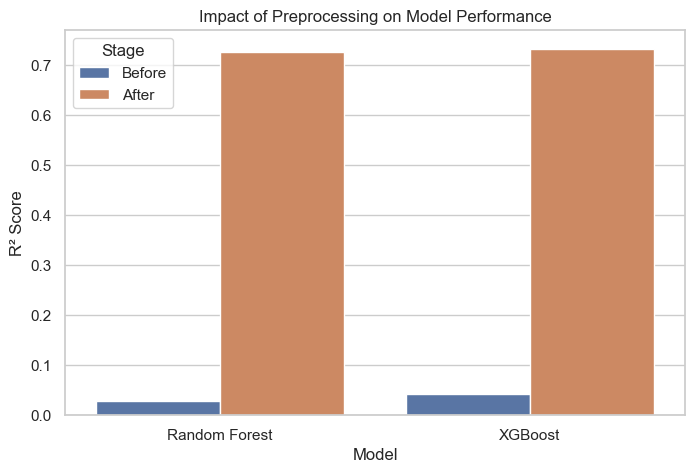

In [28]:
df_raw = df_original.copy()
df_raw = df_raw.drop(columns=['street', 'city', 'date', 'country', 'statezip'])

X_raw = df_raw.drop(columns=['price'])
y_raw = df_raw['price']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

compare_results = []

for name, model in [('Random Forest', RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42)),
                     ('XGBoost', XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, objective='reg:squarederror', random_state=42))]:
    m = clone(model)
    m.fit(X_train_raw, y_train_raw)
    p = m.predict(X_test_raw)
    compare_results.append({'Stage': 'Before', 'Model': name, 'R2': r2_score(y_test_raw, p), 'RMSE': np.sqrt(mean_squared_error(y_test_raw, p))})

    m2 = clone(model)
    m2.fit(X_train_scaled, y_train)
    p2 = m2.predict(X_test_scaled)
    compare_results.append({'Stage': 'After', 'Model': name, 'R2': r2_score(y_test, p2), 'RMSE': np.sqrt(mean_squared_error(y_test, p2))})

compare_df = pd.DataFrame(compare_results)
display(compare_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=compare_df, x='Model', y='R2', hue='Stage')
plt.title('Impact of Preprocessing on Model Performance')
plt.ylabel('R² Score')
plt.show()

## Residual Analysis of Best Stacking Model

To further evaluate model performance, residual analysis was conducted using the best-performing stacking model.

Three visualisations are used:
- **Predicted vs Actual plot**
- **Residual plot**
- **Residual distribution**

### Predicted vs Actual

The scatter plot compares predicted values with actual house prices.

- Points close to the diagonal line indicate accurate predictions.
- The model generally follows the trend well, suggesting good overall fit.
- Some dispersion at higher price ranges indicates increased prediction difficulty for expensive properties.

### Residual Plot

The residual plot shows prediction errors against predicted values.

- Residuals are roughly centred around zero, indicating no strong systematic bias.
- The spread of residuals increases slightly for higher predicted values, suggesting potential heteroscedasticity.
- This implies that the model performs better on mid-range properties than on extreme values.

### Residual Distribution

The histogram of residuals provides insight into error distribution.

- Residuals are approximately normally distributed around zero.
- A near-zero mean indicates that the model is not consistently over- or under-predicting.
- Slight skewness may indicate remaining modelling limitations.

### Insight

Overall, the residual analysis confirms that the stacking model achieves a strong fit with relatively unbiased predictions.  
However, increased variance in high-value predictions suggests that modelling extreme house prices remains challenging.

This highlights a common limitation in real estate modelling, where high-priced properties exhibit greater variability and are harder to predict accurately.

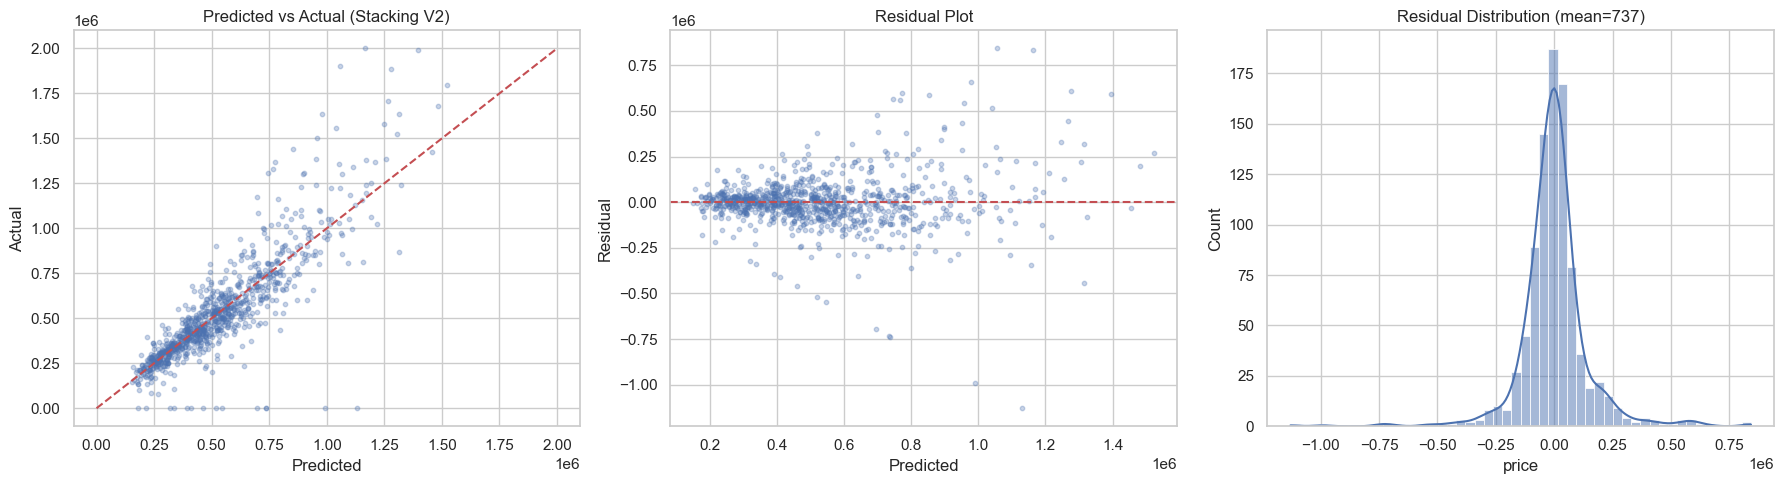

In [29]:
best_preds = [y_pred_v1, y_pred_v2, y_pred_v3][best_v]
best_name = ['V1', 'V2', 'V3'][best_v]
residuals = y_test - best_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(best_preds, y_test.values, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Predicted vs Actual (Stacking {best_name})')

axes[1].scatter(best_preds, residuals, alpha=0.3, s=10)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

sns.histplot(residuals, bins=50, kde=True, ax=axes[2])
axes[2].set_title(f'Residual Distribution (mean={residuals.mean():.0f})')

plt.tight_layout()
plt.show()

画图，后续删除

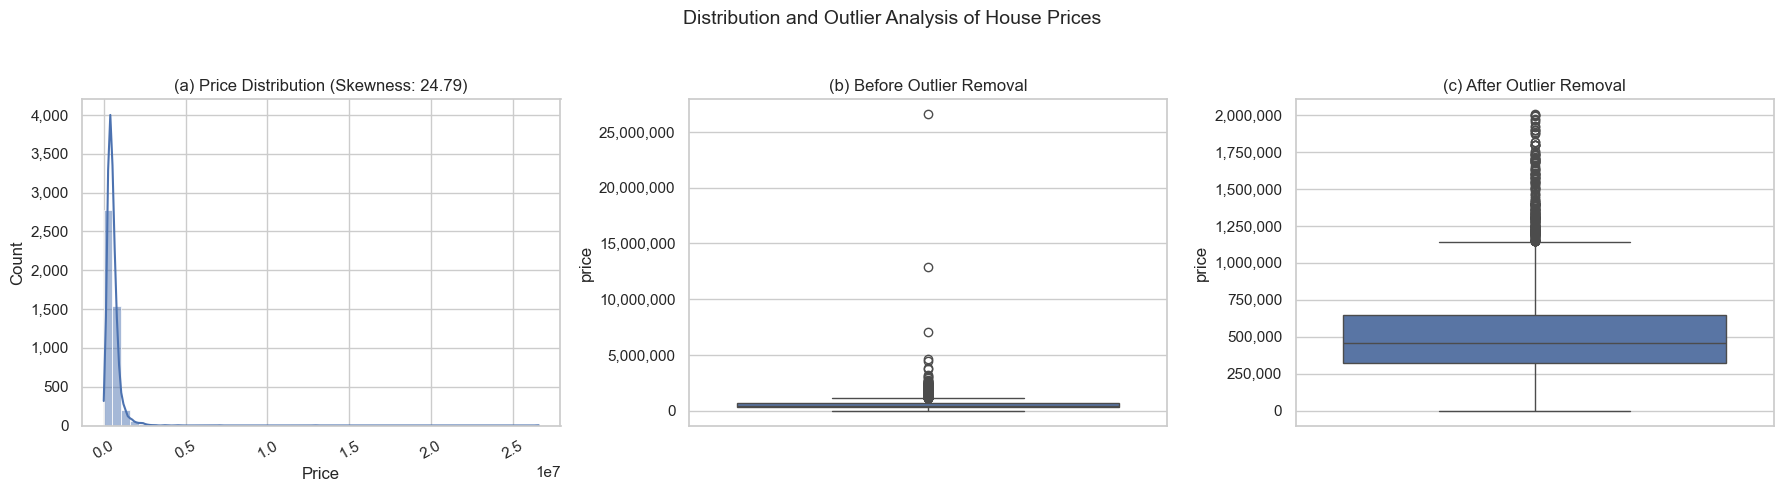

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ===== (a) Distribution =====
sns.histplot(df['price'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('(a) Price Distribution (Skewness: 24.79)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

# ===== (b) Before =====
sns.boxplot(y=df['price'], ax=axes[1])
axes[1].set_title('(b) Before Outlier Removal')

# ===== (c) After =====
sns.boxplot(y=df_cleaned['price'], ax=axes[2])
axes[2].set_title('(c) After Outlier Removal')

# ===== 美化 =====
for ax in axes:
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.tick_params(axis='x', rotation=30)

# ⭐ 总标题（论文里不会显示，用于本地查看）
fig.suptitle('Distribution and Outlier Analysis of House Prices', fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# ===== ⭐ 关键：保存 =====
plt.savefig(
    "output.png",   # 文件名（建议和论文一致）
    dpi=300,               # 高分辨率（论文必须）
    bbox_inches='tight'    # 去掉多余空白
)

plt.show()

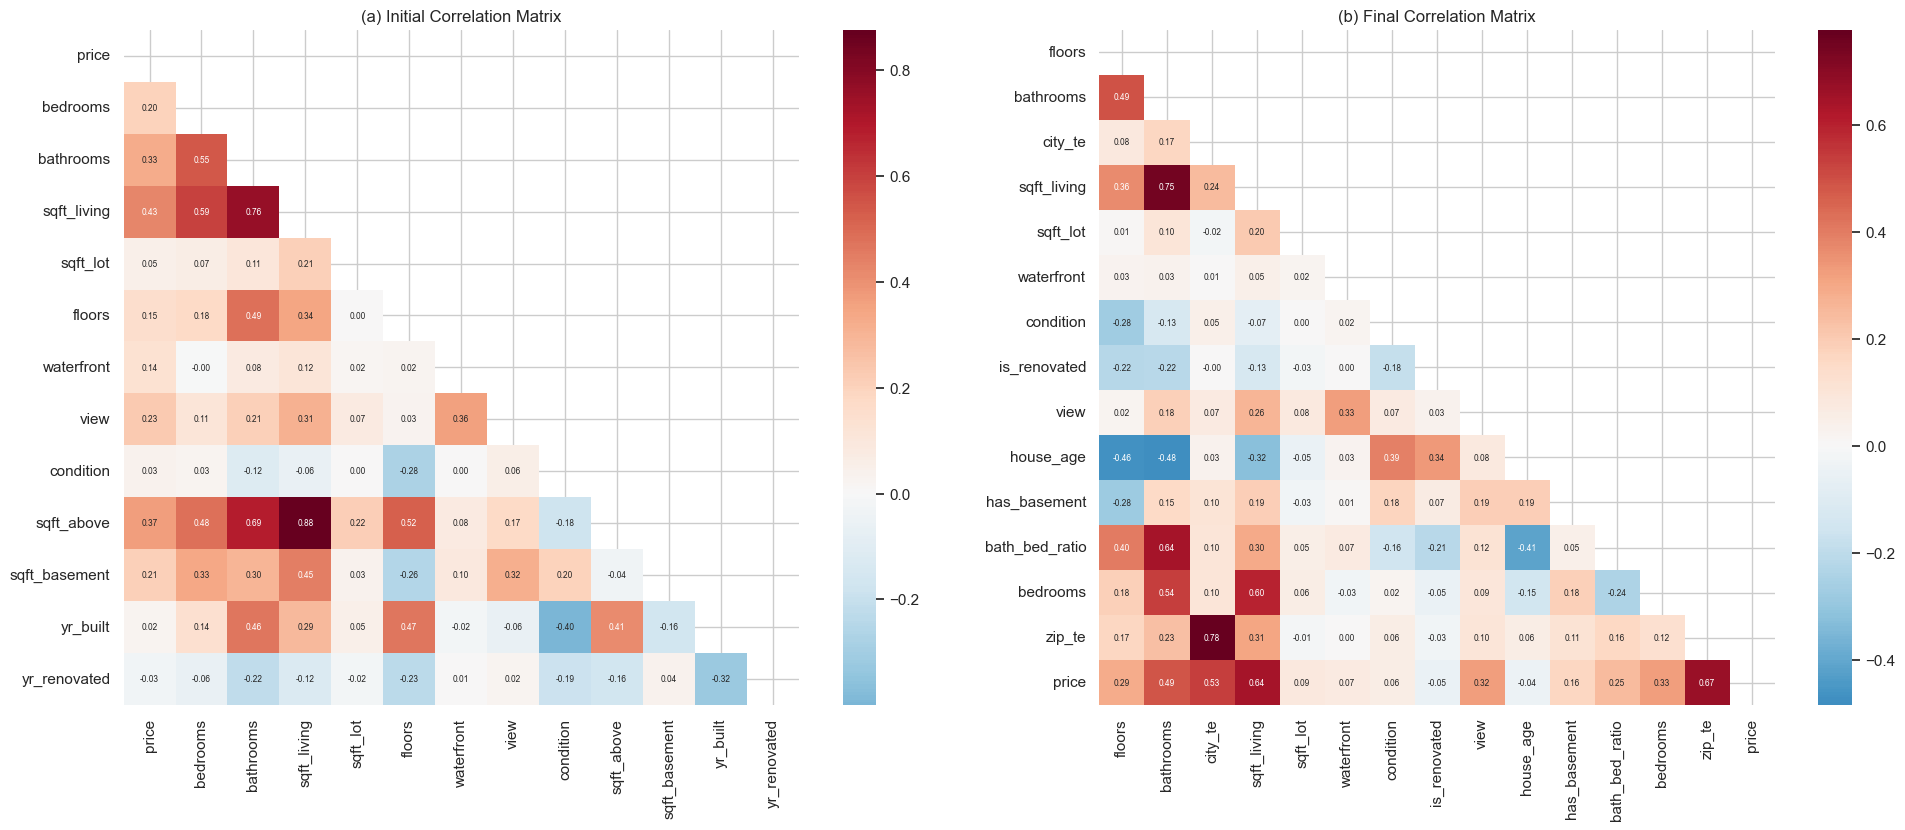

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))  # 放大画布

# ===== (a) Initial =====
sns.heatmap(
    corr,
    mask=np.triu(np.ones_like(corr, dtype=bool)),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    annot_kws={"size": 6},   # 👈 关键：缩小字体
    ax=axes[0]
)
axes[0].set_title('(a) Initial Correlation Matrix', fontsize=12)

# ===== (b) Final =====
sns.heatmap(
    final_corr,
    mask=np.triu(np.ones_like(final_corr, dtype=bool)),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    annot_kws={"size": 6},   # 👈 同样缩小
    ax=axes[1]
)
axes[1].set_title('(b) Final Correlation Matrix', fontsize=12)

plt.tight_layout()
plt.savefig("corr_comparison.png", dpi=300)
plt.show()